In [3]:
import pandas as pd
import numpy as np


In [4]:
# Read the CSV file
file_path = '8-combined_url_BERT+AV+title _4labels.csv'
df = pd.read_csv(file_path)

# Check the data
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(df.head())


Shape: (661, 4614)
Columns: ['url', 'title', 'label', 'title_0', 'title_1', 'title_2', 'title_3', 'title_4', 'title_5', 'title_6', 'title_7', 'title_8', 'title_9', 'title_10', 'title_11', 'title_12', 'title_13', 'title_14', 'title_15', 'title_16', 'title_17', 'title_18', 'title_19', 'title_20', 'title_21', 'title_22', 'title_23', 'title_24', 'title_25', 'title_26', 'title_27', 'title_28', 'title_29', 'title_30', 'title_31', 'title_32', 'title_33', 'title_34', 'title_35', 'title_36', 'title_37', 'title_38', 'title_39', 'title_40', 'title_41', 'title_42', 'title_43', 'title_44', 'title_45', 'title_46', 'title_47', 'title_48', 'title_49', 'title_50', 'title_51', 'title_52', 'title_53', 'title_54', 'title_55', 'title_56', 'title_57', 'title_58', 'title_59', 'title_60', 'title_61', 'title_62', 'title_63', 'title_64', 'title_65', 'title_66', 'title_67', 'title_68', 'title_69', 'title_70', 'title_71', 'title_72', 'title_73', 'title_74', 'title_75', 'title_76', 'title_77', 'title_78', 'title_7

In [5]:
df

,url,title,label,title_0,title_1,title_2,title_3,title_4,title_5,title_6,...,audio_130,audio_131,audio_132,audio_133,audio_134,audio_135,audio_136,audio_137,audio_138,audio_139
0,https://youtube.com/shorts/aa4rZp_vfS4?si=2t9E...,['ducking save seriously injured cat #duckresc...,Explicit,-0.433471,-0.094420,-0.042714,-0.085980,-0.236279,-0.001080,0.406059,...,-0.021403,0.102465,0.018431,0.167551,0.018082,0.166489,0.010044,0.055793,0.000368,0.058593
1,https://youtube.com/shorts/LBK1qGei-Sg?si=RiET...,['🫣😄\u200bأقوى المقاطع المضحكة للحمير – لن تتو...,Explicit,-0.322783,0.016058,-0.439717,-0.597225,-0.381793,-0.232311,0.345304,...,0.004436,0.048084,-0.009294,0.049872,0.014628,0.050712,0.002623,0.017251,0.002907,0.025290
2,https://youtube.com/shorts/Q304WXr0fDU?si=AYIe...,['#momcozy#momlife#baby AA 501 #mother'],Explicit,-0.397050,-0.140791,0.209589,0.047261,-0.157481,-0.369283,0.626168,...,-0.116879,0.110252,-0.055603,0.102578,-0.028009,0.244705,-0.033516,0.061555,0.028123,0.076075
3,https://youtube.com/shorts/s6NJ-0lfRD8?si=qPbL...,['🐐🤭#viralshots #youtubeshorts #goat #beautifu...,Explicit,0.245136,0.226259,-0.178050,-0.074773,-0.697731,-0.176577,0.960821,...,-0.005206,0.107299,-0.016909,0.114603,-0.017748,0.100660,0.015117,0.039018,-0.007634,0.038970
4,https://youtube.com/shorts/YJQPjPWU0dM?si=BhqG...,['01-Jul-26'],Explicit,-1.010023,-0.535633,-0.584655,0.157270,-0.398348,-0.583174,0.186172,...,-0.007741,0.074713,-0.017476,0.072241,-0.037804,0.046258,0.001086,0.022727,-0.031146,0.023914
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
656,https://youtube.com/shorts/UHVRuJLmpeg?si=cQq6...,['Riddhima Sharma vs Chandrika Dixit: Vada Pav...,Toxic,0.073782,-0.263064,0.544321,-0.153550,-0.416935,-0.529121,0.474669,...,0.001411,0.127949,0.000591,0.191747,-0.002066,0.178739,0.003570,0.070858,-0.011562,0.060945
657,https://youtube.com/shorts/fjDUJNfHpaM?si=1XFr...,['Riddhima Sharma ने kanika Sharma को बताया ब्...,Toxic,-0.204639,-0.154523,-0.097439,-0.150117,-0.429983,-0.047936,0.429055,...,0.104536,0.096084,-0.164294,0.151530,0.018247,0.135776,-0.041684,0.055061,-0.034639,0.049502
658,https://youtube.com/shorts/DQ-py4VFjDI?si=efP5...,['Riddhima sharma on rock #hindu #mamtabanerje...,Toxic,-0.649939,0.050414,-0.088262,-0.052796,-0.688245,0.049723,0.974675,...,0.007656,0.116003,-0.010736,0.164767,0.017211,0.145972,-0.001065,0.059322,-0.004482,0.053704
659,https://youtube.com/shorts/2b_XYeNIOQ0?si=x-C-...,['A Haryana Girl Came to CJP Protest Jantar Ma...,Toxic,-0.406257,-0.269516,-0.285115,-0.378727,-0.845065,0.054872,0.159439,...,-0.010695,0.134201,0.024080,0.189207,0.005616,0.200190,-0.008174,0.072525,-0.006270,0.062977


In [6]:
class_labels = df["label"].unique().tolist()
print(class_labels)

['Explicit', 'Violence', 'Toxic', 'Normal']


In [7]:
# Separate features, filename, and class ; first column is filename, last column is class
X = df.drop(columns=["url","title", "label"])
y = df["label"]

Lebel encoders

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_encoded

array([0, 0, 0, 0, 0, 3, 2, 0, 2, 0, 2, 0, 2, 2, 3, 3, 0, 2, 2, 2, 0, 2,
       2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 0, 0, 3, 3, 3, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 1, 3, 0, 1, 3, 0, 1, 1, 1, 2, 0, 3, 0, 1, 1, 0,
       1, 1, 2, 3, 1, 2, 2, 3, 1, 2, 1, 3, 1, 1, 0, 3, 0, 1, 1, 1, 2, 1,
       2, 1, 1, 2, 1, 1, 1, 1, 2, 3, 2, 1, 2, 0, 1, 1, 1, 0, 0, 0, 3, 2,
       1, 0, 0, 2, 0, 2, 1, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 0,
       2, 1, 0, 1, 0, 2, 1, 0, 0, 2, 1, 1, 1, 1, 1, 1, 0, 2, 0, 1, 3, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 2, 0, 1, 3, 1, 0, 1, 1, 1, 1, 1,
       3, 1, 0, 1, 1, 1, 1, 0, 0, 1, 3, 2, 1, 3, 2, 3, 1, 1, 1, 1, 1, 0,
       2, 1, 1, 0, 3, 3, 1, 0, 1, 3, 1, 2, 0, 1, 2, 1, 2, 2, 2, 1, 2, 3,
       3, 1, 2, 1, 2, 2, 1, 0, 1, 0, 0, 2, 1, 1, 0, 1, 3, 3, 0, 0, 3, 0,
       0, 3, 1, 2, 2, 1, 2, 0, 2, 3, 1, 3, 3, 0, 0, 1, 1, 3, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

Class to numeric mapping

In [9]:
# Visualize class to  numeric mapping
class_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("\nClass to Numeric Mapping:")
for class_name, numeric in class_mapping.items():
    print(f"  {class_name} -> {numeric}")


Class to Numeric Mapping:
  Explicit -> 0
  Normal -> 1
  Toxic -> 2
  Violence -> 3


# Step 3: Split into train and test data (80% train, 20% test)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=44,
    stratify=y_encoded  # Maintains class balance
)

In [11]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [12]:
# slect best model
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from xgboost import XGBRegressor

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, solver="saga", random_state=42),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric="mlogloss"),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(128, 64, 32),max_iter=300,random_state=42)}

# Check if scaling is needed

In [13]:
needs_scaling = (X.mean().abs() > 0.01).any() or ((X.std() - 1).abs() > 0.01).any()

In [14]:
print(f"Needs Scaling: {needs_scaling}")
print(f"Max |Mean|: {X.mean().abs().max():.4f}")
print(f"Max |Std - 1|: {(X.std() - 1).abs().max():.4f}")

Needs Scaling: True
Max |Mean|: 4010.6873
Max |Std - 1|: 1041.6202


In [15]:
if needs_scaling:
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
else:
    X_train_scaled = X_train
    X_test_scaled = X_test

In [16]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [17]:
for name, model in models.items():
    if name in ["Logistic Regression", "KNN", "SVM", "Neural Network"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

Show best model

In [18]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



Training Logistic Regression...
Accuracy: 0.6015


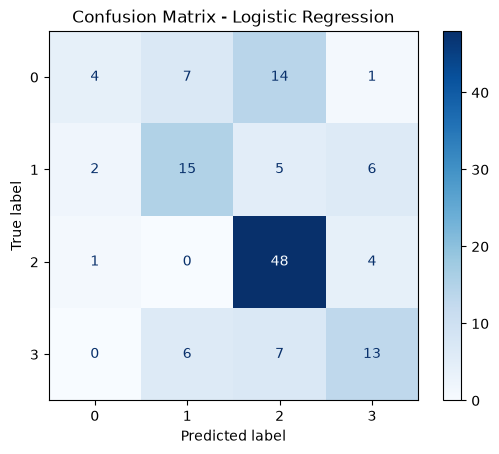


Training Naive Bayes...
Accuracy: 0.7820


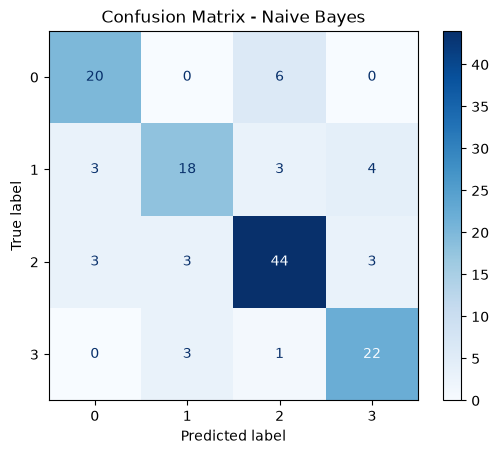


Training KNN...
Accuracy: 0.4211


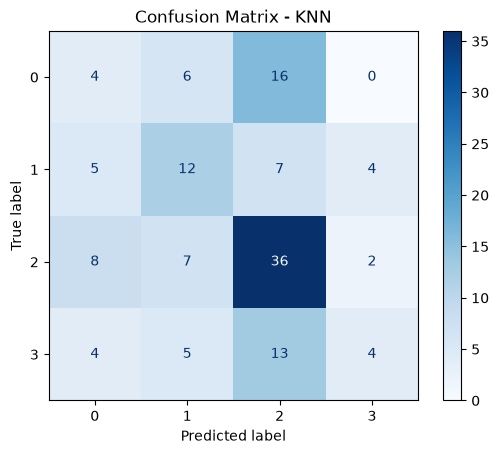


Training Decision Tree...
Accuracy: 0.6391


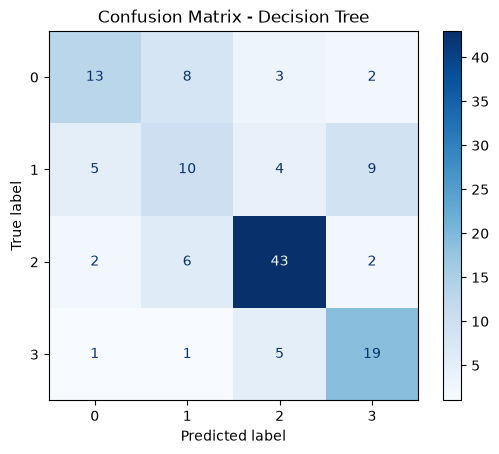


Training Random Forest...
Accuracy: 0.8271


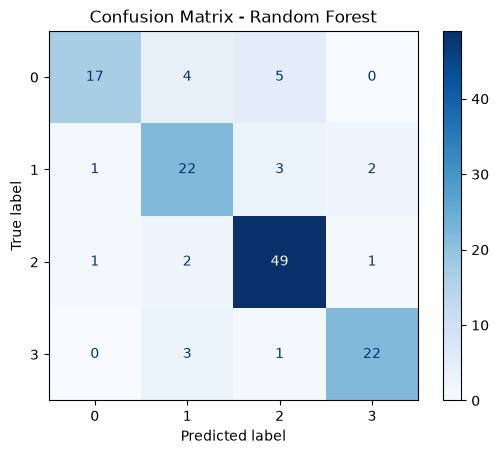


Training AdaBoost...
Accuracy: 0.8271


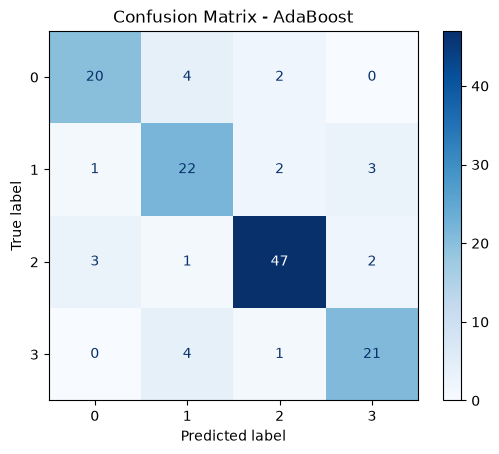


Training Gradient Boosting...
Accuracy: 0.8346


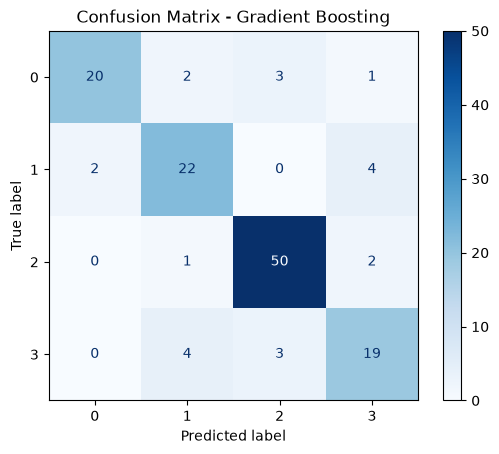


Training XGBoost...
Accuracy: 0.8571


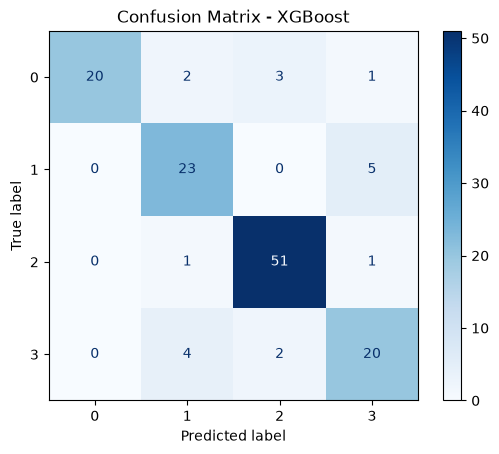


Training SVM...
Accuracy: 0.4586


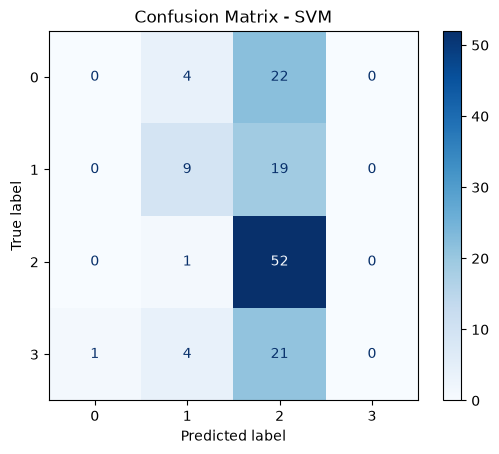


Training Neural Network...
Accuracy: 0.8947


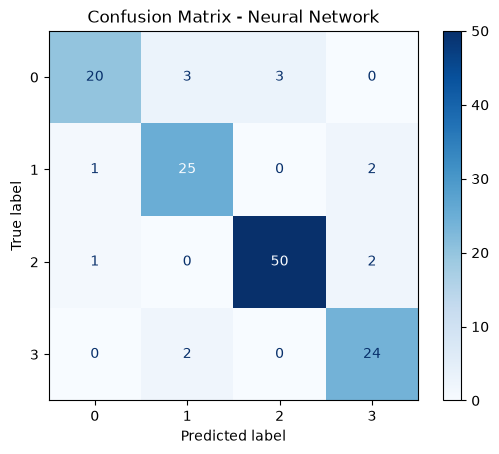

In [19]:
# Compare all models
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt
results = {}
for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Evaluate
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy

    print(f"Accuracy: {accuracy:.4f}")

    # confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues", values_format='d')

    plt.title(f"Confusion Matrix - {name}")
    plt.show()

In [20]:
results_df1 = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
print(results_df1)

                 Model  Accuracy
0  Logistic Regression  0.601504
1          Naive Bayes  0.781955
2                  KNN  0.421053
3        Decision Tree  0.639098
4        Random Forest  0.827068
5             AdaBoost  0.827068
6    Gradient Boosting  0.834586
7              XGBoost  0.857143
8                  SVM  0.458647
9       Neural Network  0.894737


In [21]:
best_model= max(results, key=results.get)
print(f"\n{'='*50}")
print("BEST MODEL:")
best_model_name = max(results, key=results.get)
print(f"{best_model} with accuracy: {results[best_model]:.4f}")


BEST MODEL:
Neural Network with accuracy: 0.8947


In [22]:
results_df1 = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
print(results_df1)

                 Model  Accuracy
0  Logistic Regression  0.601504
1          Naive Bayes  0.781955
2                  KNN  0.421053
3        Decision Tree  0.639098
4        Random Forest  0.827068
5             AdaBoost  0.827068
6    Gradient Boosting  0.834586
7              XGBoost  0.857143
8                  SVM  0.458647
9       Neural Network  0.894737


K-fold stratefication

In [23]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
import pandas as pd

le = LabelEncoder()
y_encoded = le.fit_transform(y)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='weighted'),
    'recall': make_scorer(recall_score, average='weighted'),
    'f1': make_scorer(f1_score, average='weighted')
}

results = []

for name, model in models.items():
    if name in ["Logistic Regression", "KNN", "SVM", "Neural Network"]:
        estimator = Pipeline([("scaler", StandardScaler()), ("model", model)])
    else:
        estimator = model

    scores = cross_validate(
        estimator,
        X,
        y_encoded,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    results.append({
        "Model": name,
        "Accuracy": scores['test_accuracy'].mean(),
        "Precision": scores['test_precision'].mean(),
        "Recall": scores['test_recall'].mean(),
        "F1-Score": scores['test_f1'].mean()
    })

results_df2 = pd.DataFrame(results)
print(results_df2)

                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.841183   0.842159  0.841183  0.840288
1          Naive Bayes  0.760971   0.761785  0.760971  0.757836
2                  KNN  0.723183   0.749392  0.723183  0.708063
3        Decision Tree  0.639918   0.648946  0.639918  0.642191
4        Random Forest  0.806334   0.808009  0.806334  0.803152
5             AdaBoost  0.789667   0.799707  0.789667  0.788080
6    Gradient Boosting  0.835167   0.839900  0.835167  0.831641
7              XGBoost  0.847232   0.853318  0.847232  0.844562
8                  SVM  0.818432   0.824333  0.818432  0.817011
9       Neural Network  0.839576   0.843325  0.839576  0.838918
